<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT007d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

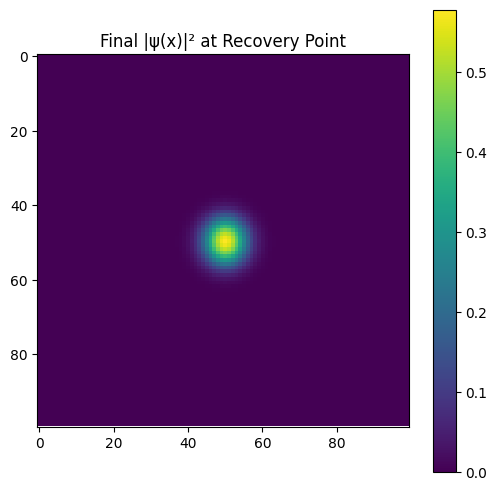

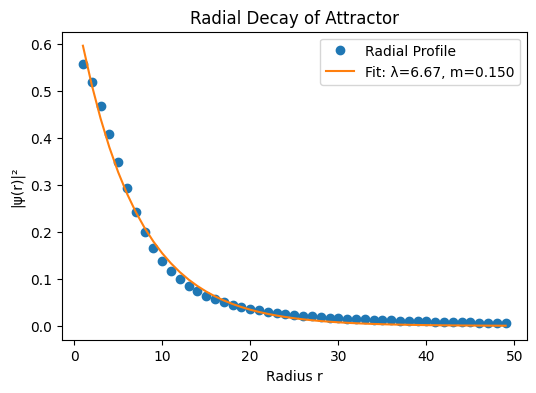

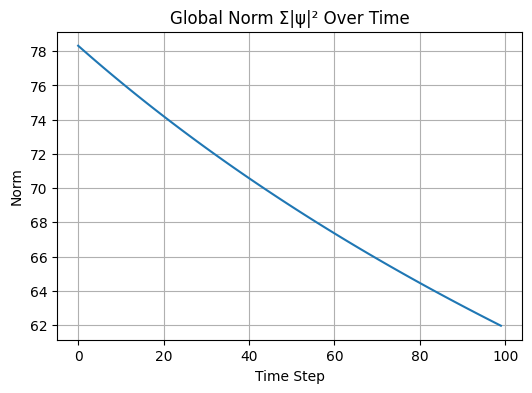

In [1]:
# QFT007d: Recovery Test — γ = 0.08, ε = 0.02
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Parameters
N = 100          # Lattice size
T = 100          # Time steps
gamma = 0.08     # Diffusion strength
epsilon = 0.02   # Memory strength
A = 1.0          # Seed amplitude
sigma = 5.0      # Seed width

# Seed initialization: Gaussian bump at center
x0, y0 = N//2, N//2
X, Y = np.meshgrid(np.arange(N), np.arange(N))
psi = A * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2)) + 1j * np.zeros((N, N))

# Track global norm
norms = []

# Evolution loop
for t in range(T):
    psi_new = np.copy(psi)
    for i in range(N):
        for j in range(N):
            ip, im = (i+1)%N, (i-1)%N
            jp, jm = (j+1)%N, (j-1)%N

            # 9-point Laplacian
            laplacian = (
                (psi[ip,j] + psi[im,j] + psi[i,jp] + psi[i,jm]) / 6 +
                (psi[ip,jp] + psi[ip,jm] + psi[im,jp] + psi[im,jm]) / 12 -
                psi[i,j]
            )
            diffusion = gamma * laplacian

            # Symmetric memory compensation
            delta_A2 = (
                np.abs(psi[ip,j])**2 + np.abs(psi[im,j])**2 - 2 * np.abs(psi[i,j])**2
            )
            compensation = epsilon * delta_A2

            # Update rule
            psi_new[i,j] = psi[i,j] + diffusion + compensation
    psi = psi_new
    norms.append(np.sum(np.abs(psi)**2))

# Final magnitude
magnitude = np.abs(psi)**2

# Radial profile extraction
radii = []
values = []
for r in range(1, N//2):
    shell = magnitude[x0-r:x0+r+1, y0-r:y0+r+1]
    shell_mean = np.mean(shell)
    radii.append(r)
    values.append(shell_mean)

# Fit exponential decay: |ψ(r)|² ~ exp(-r / λ_c)
def decay_func(r, a, lambda_c):
    return a * np.exp(-r / lambda_c)

try:
    params, _ = curve_fit(decay_func, radii, values, p0=(1.0, 10.0))
    lambda_c = params[1]
    mass = 1 / lambda_c
except:
    lambda_c = np.nan
    mass = np.nan

# Plot final field
plt.figure(figsize=(6, 6))
plt.imshow(magnitude, cmap='viridis')
plt.title('Final |ψ(x)|² at Recovery Point')
plt.colorbar()
plt.show()

# Plot radial decay and fit
plt.figure(figsize=(6, 4))
plt.plot(radii, values, 'o', label='Radial Profile')
if not np.isnan(mass):
    plt.plot(radii, decay_func(np.array(radii), *params), '-', label=f'Fit: λ={lambda_c:.2f}, m={mass:.3f}')
plt.title('Radial Decay of Attractor')
plt.xlabel('Radius r')
plt.ylabel('|ψ(r)|²')
plt.legend()
plt.show()

# Plot global norm over time
plt.figure(figsize=(6, 4))
plt.plot(norms)
plt.title('Global Norm Σ|ψ|² Over Time')
plt.xlabel('Time Step')
plt.ylabel('Norm')
plt.grid(True)
plt.show()
